# Phase 6 — Cross-Industry Analysis

1. Brand-level risk scores (proportions, not raw counts)
2. Own-operations vs supply-chain breakdown
3. Proprietary standard flag rates by brand
4. Nearest-neighbour qualitative examples (top 5 per brand)
5. Cross-industry feature comparison (fashion vs clean beauty)

In [1]:
import json
from pathlib import Path
from textwrap import fill

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ROOT     = Path('..').resolve()
RESULTS  = ROOT / 'results'
RAW_DIR  = ROOT / 'data' / 'raw'
RESULTS.mkdir(parents=True, exist_ok=True)

# Load all predictions and features
knn_df   = pd.read_parquet(RESULTS / 'knn_predictions.parquet')
tfidf_df = pd.read_parquet(RESULTS / 'tfidf_predictions.parquet')
cb_df    = pd.read_parquet(RESULTS / 'climatebert_predictions.parquet')
feat_df  = pd.read_parquet(RAW_DIR / 'features' / 'features.parquet')

# Load corpus texts for qualitative display
with open(RAW_DIR / 'extracted' / 'passages.jsonl') as f:
    corpus = [json.loads(l) for l in f]
corpus_df = pd.DataFrame(corpus)

# Load labeled training set for nearest-neighbor display
with open(RAW_DIR / 'labeled' / 'labeled_passages.jsonl') as f:
    labeled = [json.loads(l) for l in f]

# Merge everything on passage_id
df = knn_df.merge(feat_df, on=['passage_id', 'brand', 'industry', 'role']) \
           .merge(tfidf_df[['passage_id', 'tfidf_pred', 'tfidf_prob']], on='passage_id') \
           .merge(cb_df[['passage_id', 'cb_label', 'cb_score']], on='passage_id')

print(f"Merged dataframe: {len(df):,} rows × {len(df.columns)} columns")
df.head(3)

Merged dataframe: 1,279 rows × 19 columns


,passage_id,brand,industry,role,knn_pred,knn_prob,nn_indices,nn_distances,hedge_density,proprietary_flag,has_quant_target,scope,flesch_kincaid_grade,beauty_term_flag,text_length_chars,tfidf_pred,tfidf_prob,cb_label,cb_score
0,0,H&M,fashion,greenwashing,1,0.6667,"[2, 3, 22]","[0.45058029890060425, 0.4658395051956177, 0.49...",0.000000,0,1,supply_chain,21.631538,0,2031,0,0.4325,LABEL_1,0.5021
1,1,H&M,fashion,greenwashing,0,0.0000,"[6, 47, 22]","[0.4513722062110901, 0.5031845569610596, 0.523...",0.002451,0,1,supply_chain,28.881716,0,2639,0,0.4755,LABEL_0,0.5028
2,2,H&M,fashion,greenwashing,0,0.3333,"[25, 32, 47]","[0.6186090707778931, 0.6785476207733154, 0.734...",0.000000,1,1,mixed,11.682049,0,2812,0,0.3567,LABEL_0,0.5028


## Section 1 — Brand-level risk scores

All scores are proportions (mean greenwash probability per brand), not raw counts. This controls for report length imbalance across brands.

    brand     industry             role  passage_count  mean_knn_prob  mean_tfidf_prob  pct_knn_flagged
  L'Oreal clean_beauty     greenwashing             19         0.3684           0.4550           0.2632
  Sephora clean_beauty     greenwashing             95         0.3017           0.4092           0.1474
     Zara      fashion     greenwashing            385         0.0978           0.3563           0.0416
      H&M      fashion     greenwashing            414         0.0950           0.3490           0.0700
Patagonia      fashion positive_control            306         0.0599           0.3305           0.0163
     Lush clean_beauty positive_control             60         0.0333           0.3168           0.0000

Positive controls: ['Patagonia', 'Lush']


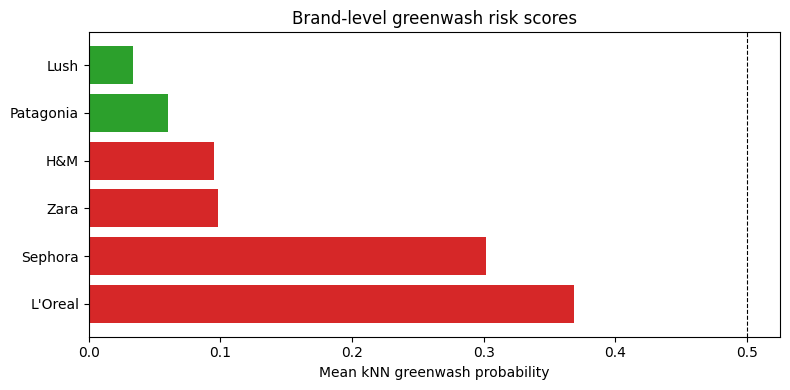

In [3]:
brand_scores = df.groupby(['brand', 'industry', 'role']).agg(
    passage_count   = ('passage_id', 'count'),
    mean_knn_prob   = ('knn_prob', 'mean'),
    mean_tfidf_prob = ('tfidf_prob', 'mean'),
    pct_knn_flagged = ('knn_pred', 'mean'),   # proportion predicted greenwash
).round(4).reset_index()
brand_scores.sort_values('mean_knn_prob', ascending=False, inplace=True)

print(brand_scores.to_string(index=False))

# Sanity check: positive controls (Patagonia, Lush) should rank lowest
controls = brand_scores[brand_scores['role'] == 'positive_control']['brand'].tolist()
print(f"\nPositive controls: {controls}")

brand_scores.to_csv(RESULTS / 'brand_risk_scores.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728' if r == 'greenwashing' else '#2ca02c'
          for r in brand_scores['role']]
ax.barh(brand_scores['brand'], brand_scores['mean_knn_prob'], color=colors)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
ax.set(xlabel='Mean kNN greenwash probability', title='Brand-level greenwash risk scores')
plt.tight_layout()
plt.show()

## Section 2 — Own-operations vs supply-chain breakdown

Key insight from pilot reading: companies can make truthful own-operations claims while supply-chain claims remain vague. This test operationalises that observation.

           own_ops  supply_chain
brand                           
H&M         0.0909        0.1033
L'Oreal        NaN        0.4762
Lush           NaN        0.0454
Patagonia   0.1852        0.0482
Sephora     0.1666        0.3333
Zara        0.0860        0.1018

Supply-chain > own-ops in 3/4 brands


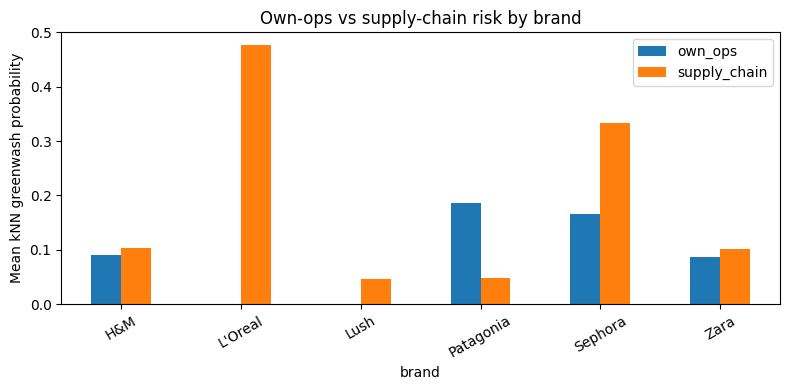

Updated → /Users/mandy.sun/green-claims-nlp/results/brand_risk_scores.csv


In [4]:
scope_breakdown = df[df['scope'].isin(['own_ops', 'supply_chain'])].groupby(
    ['brand', 'scope']
).agg(
    n             = ('passage_id', 'count'),
    mean_knn_prob = ('knn_prob', 'mean'),
).round(4).reset_index()

scope_pivot = scope_breakdown.pivot(index='brand', columns='scope', values='mean_knn_prob')
scope_pivot.columns.name = None
print(scope_pivot.to_string())

# Hypothesis: supply_chain > own_ops across all brands
brands_with_both = scope_pivot.dropna()
supply_higher = (brands_with_both['supply_chain'] > brands_with_both['own_ops']).sum()
print(f"\nSupply-chain > own-ops in {supply_higher}/{len(brands_with_both)} brands")

fig, ax = plt.subplots(figsize=(8, 4))
scope_pivot[['own_ops', 'supply_chain']].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set(ylabel='Mean kNN greenwash probability', title='Own-ops vs supply-chain risk by brand')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Save extended brand risk table
brand_risk_full = brand_scores.merge(
    scope_pivot.reset_index().rename(columns={
        'own_ops': 'own_ops_prob',
        'supply_chain': 'supply_chain_prob',
    }),
    on='brand', how='left',
)
brand_risk_full.to_csv(RESULTS / 'brand_risk_scores.csv', index=False)
print(f"Updated → {RESULTS / 'brand_risk_scores.csv'}")

## Section 3 — Proprietary standard flag analysis

Proprietary standard flag rate by brand:
    brand   n  proprietary_rate  mean_knn_prob
      H&M 414            0.1135         0.0950
     Zara 385            0.0883         0.0978
  Sephora  95            0.0211         0.3017
Patagonia 306            0.0131         0.0599
  L'Oreal  19            0.0000         0.3684
     Lush  60            0.0000         0.0333

Mean kNN prob by proprietary_flag:
proprietary_flag
0    0.1037
1    0.1073
Name: knn_prob, dtype: float64


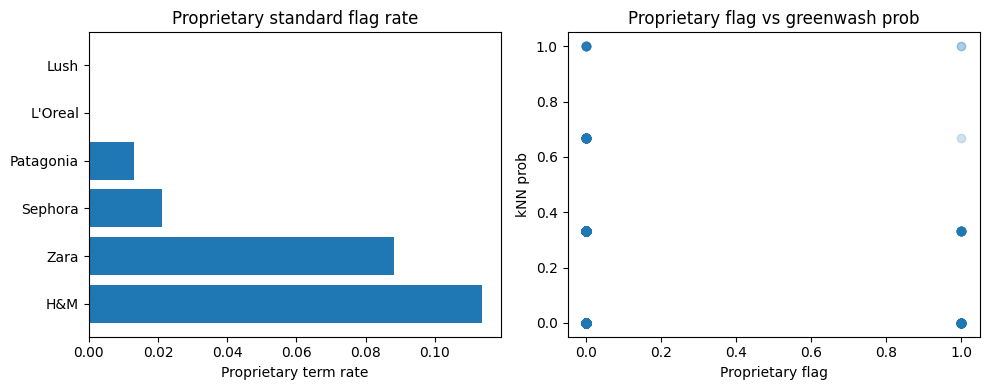

In [5]:
prop_rates = df.groupby('brand').agg(
    n                  = ('passage_id', 'count'),
    proprietary_rate   = ('proprietary_flag', 'mean'),
    mean_knn_prob      = ('knn_prob', 'mean'),
).round(4).reset_index().sort_values('proprietary_rate', ascending=False)

print("Proprietary standard flag rate by brand:")
print(prop_rates.to_string(index=False))

# Cross-tabulate: proprietary flag vs greenwash probability
print("\nMean kNN prob by proprietary_flag:")
print(df.groupby('proprietary_flag')['knn_prob'].mean().round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].barh(prop_rates['brand'], prop_rates['proprietary_rate'])
axes[0].set(xlabel='Proprietary term rate', title='Proprietary standard flag rate')
axes[1].scatter(df['proprietary_flag'], df['knn_prob'], alpha=0.2)
axes[1].set(xlabel='Proprietary flag', ylabel='kNN prob', title='Proprietary flag vs greenwash prob')
plt.tight_layout()
plt.show()

## Section 4 — Nearest-neighbour qualitative analysis

For each brand, show the 5 highest-scoring passages with their top-3 nearest labeled training examples.

In [6]:
corpus_text_map = {p['passage_id']: p['text'] for p in corpus}
qual_lines = []

for brand in df['brand'].unique():
    brand_df = df[df['brand'] == brand].nlargest(5, 'knn_prob')
    qual_lines.append(f"\n{'='*72}\n## {brand}\n{'='*72}")

    for _, row in brand_df.iterrows():
        text  = corpus_text_map.get(row['passage_id'], '')
        prob  = row['knn_prob']
        nn_ix = row['nn_indices'][:3]
        nn_ds = row['nn_distances'][:3]

        entry = [
            f"\n**Passage {row['passage_id']}** | kNN prob = {prob:.3f} | scope = {row['scope']}",
            f"proprietary_flag = {row['proprietary_flag']} | hedge_density = {row['hedge_density']:.3f}",
            "",
            fill(text[:600], 72),
            "",
            "Top-3 nearest labeled neighbors:",
        ]
        for rank, (idx, dist) in enumerate(zip(nn_ix, nn_ds), 1):
            if idx < len(labeled):
                nb = labeled[idx]
                label_name = {0: 'substantive', 1: 'greenwash-risk', 2: 'ambiguous'}[nb['label']]
                entry.append(f"  {rank}. [{label_name}] dist={dist:.3f} — {nb['text'][:120]}...")
        qual_lines.append('\n'.join(entry))

qual_text = '\n'.join(qual_lines)
qual_path = RESULTS / 'qualitative_examples.md'
with open(qual_path, 'w') as f:
    f.write(qual_text)

print(qual_text[:2000])
print(f"\n... (full text saved to {qual_path})")


## H&M

**Passage 6** | kNN prob = 1.000 | scope = unclear
proprietary_flag = 1 | hedge_density = 0.000

H&M was also ranked number one among 42 fashion companies by the
organisation Stand.earth for our efforts to reduce climate impact. H&M’s
new collaboration with Stella McCartney COS presented new collection in
New York The design director behind H&M’s creative legacy In December
H&M and renowned designer and sust ain- COS returned to New York Fashion
Week for the fourth ‘Team Maggan’, a book published this year, tells the
story of ability pioneer Stella McCartney announced a new consecutive
year, manifesting its ambition to build a Margareta van den Bosch –
H&M’s first design director who coll

Top-3 nearest labeled neighbors:
  1. [greenwash-risk] dist=0.396 — BUSINESS MODEL Driven by design, quality and creativity H&M Group’s brands are united by the ambition to make fashion an...
  2. [greenwash-risk] dist=0.487 — shareholders, by sustaining countries For over a century we have 

## Section 5 — Cross-industry feature comparison

Industry-level feature comparison:
    industry    n  mean_hedge_density  pct_quant_target  pct_proprietary  pct_beauty_terms  mean_fk_grade  mean_knn_prob
clean_beauty  174              0.0021            0.9483           0.0115            0.7241        15.5044         0.2165
     fashion 1105              0.0027            0.7683           0.0769            0.0000        16.5141         0.0863

Fashion hedge density by scope:
scope
mixed           0.0024
own_ops         0.0027
supply_chain    0.0031
unclear         0.0024
Name: hedge_density, dtype: float64

Clean beauty hedge density by scope:
scope
mixed           0.0010
own_ops         0.0037
supply_chain    0.0024
unclear         0.0019
Name: hedge_density, dtype: float64


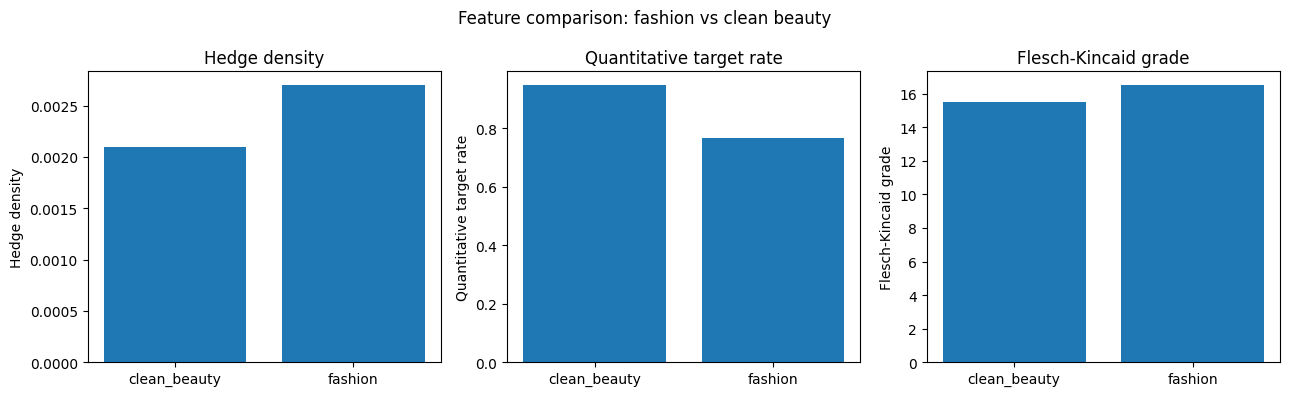

In [7]:
feat_comparison = df.groupby('industry').agg(
    n                   = ('passage_id', 'count'),
    mean_hedge_density  = ('hedge_density', 'mean'),
    pct_quant_target    = ('has_quant_target', 'mean'),
    pct_proprietary     = ('proprietary_flag', 'mean'),
    pct_beauty_terms    = ('beauty_term_flag', 'mean'),
    mean_fk_grade       = ('flesch_kincaid_grade', 'mean'),
    mean_knn_prob       = ('knn_prob', 'mean'),
).round(4).reset_index()

print("Industry-level feature comparison:")
print(feat_comparison.to_string(index=False))

feat_comparison.to_csv(RESULTS / 'feature_comparison.csv', index=False)

# Refined hypothesis: fashion supply-chain passages show higher hedge density
fashion_scope = df[df['industry'] == 'fashion'].groupby('scope')['hedge_density'].mean()
beauty_scope  = df[df['industry'] == 'clean_beauty'].groupby('scope')['hedge_density'].mean()

print("\nFashion hedge density by scope:")
print(fashion_scope.round(4))
print("\nClean beauty hedge density by scope:")
print(beauty_scope.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = [('mean_hedge_density', 'Hedge density'),
           ('pct_quant_target', 'Quantitative target rate'),
           ('mean_fk_grade', 'Flesch-Kincaid grade')]
for ax, (col, label) in zip(axes, metrics):
    ax.bar(feat_comparison['industry'], feat_comparison[col])
    ax.set(title=label, ylabel=label)
plt.suptitle('Feature comparison: fashion vs clean beauty')
plt.tight_layout()
plt.show()